In [1]:
import pandas as pd
import numpy as np
import joblib
import json
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, brier_score_loss,
                              confusion_matrix, classification_report, roc_curve)
from sklearn.inspection import permutation_importance


In [2]:
data=pd.read_spss('C:/Users/User/Downloads/Telegram Desktop/Delivery care satisfaction.sav')

In [3]:
data.head()

,q101age,q102mstatu,q103religi,q104ethini,q105educat,q106occupa,q107mincom,q108reside,q1091distk,q1092disth,...,encourageandsupportatdeliveryrecode,politenessrecode,availabilityofmedicalequipmentsrecode,counselingrecode,overallcleanessrecode,accessandcleanessoftoiletrecode,waitingareacleanessandconfort,availabilityofbedintheward,distancerecode1,wolkingdistancerecodeinhrs
0,22.0,married,orthodox,amhara,grade 5 to 8,others,800.0,rural,0.0,200.0,...,not satisfied,not satisfied,not satisfied,not satisfied,not satisfied,not satisfied,not satisfied,not satisfied,<=10 kilo meters,>2 hrs
1,35.0,married,orthodox,tigrie,grade 5 to 8,merchants,7000.0,urban,0.0,50.0,...,satisfied,satisfied,satisfied,satisfied,satisfied,satisfied,satisfied,satisfied,<=10 kilo meters,>2 hrs
2,20.0,married,orthodox,amhara,grade 9 to 10,merchants,1500.0,urban,5.0,NaN,...,satisfied,satisfied,satisfied,satisfied,satisfied,satisfied,satisfied,satisfied,<=10 kilo meters,NaN
3,26.0,married,orthodox,amhara,grade 1 to 4,huose wife,900.0,urban,0.0,11.0,...,satisfied,satisfied,satisfied,satisfied,satisfied,satisfied,satisfied,satisfied,<=10 kilo meters,>2 hrs
4,22.0,married,muslim,amhara,grade 11 to 12,students,1536.0,rural,5.0,NaN,...,satisfied,satisfied,satisfied,satisfied,satisfied,satisfied,satisfied,satisfied,<=10 kilo meters,NaN


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 894 entries, 0 to 893
Data columns (total 46 columns):
 #   Column                                 Non-Null Count  Dtype   
---  ------                                 --------------  -----   
 0   q101age                                894 non-null    float64 
 1   q102mstatu                             894 non-null    category
 2   q103religi                             894 non-null    category
 3   q104ethini                             894 non-null    category
 4   q105educat                             894 non-null    category
 5   q106occupa                             894 non-null    category
 6   q107mincom                             894 non-null    float64 
 7   q108reside                             894 non-null    category
 8   q1091distk                             894 non-null    float64 
 9   q1092disth                             320 non-null    float64 
 10  q110reason                             894 non-null    category
 11  q111

In [5]:
data['q1092disth'].isnull().sum()

np.int64(574)

In [6]:
data.columns

Index(['q101age', 'q102mstatu', 'q103religi', 'q104ethini', 'q105educat',
       'q106occupa', 'q107mincom', 'q108reside', 'q1091distk', 'q1092disth',
       'q110reason', 'q111timeta', 'q112waitpl', 'q113privac', 'q201parity',
       'q202cpplan', 'q203ancatt', 'q204hivres', 'q205ga', 'q206delimo',
       'q207nstatu', 'q208pdhsta', 'q209nsex', 'q2010bw', 'q301greeti',
       'q302respec', 'q303delive', 'q411owners', 'ageafterrecod',
       'monthlyincomerecode', 'gestationaagerecode', 'birthweightofbaby',
       'satisfaction', 'modeofdeliveryrecode', 'waitingtimerecode',
       'privacyrecode', 'encourageandsupportatdeliveryrecode',
       'politenessrecode', 'availabilityofmedicalequipmentsrecode',
       'counselingrecode', 'overallcleanessrecode',
       'accessandcleanessoftoiletrecode', 'waitingareacleanessandconfort',
       'availabilityofbedintheward', 'distancerecode1',
       'wolkingdistancerecodeinhrs'],
      dtype='str')

In [7]:
data['satisfaction'].value_counts()

satisfaction
satisfied        549
not satisfied    345
Name: count, dtype: int64

In [8]:
data['wolkingdistancerecodeinhrs'].value_counts()

wolkingdistancerecodeinhrs
>2 hrs    275
Name: count, dtype: int64

In [9]:
print(f"Number of observations (mothers): {data.shape[0]}")
print(f"Number of variables: {data.shape[1]}")
print()

Number of observations (mothers): 894
Number of variables: 46



### Numeric variable- Descriptive statistics

In [10]:
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric variables:", numeric_cols)

Numeric variables: ['q101age', 'q107mincom', 'q1091distk', 'q1092disth', 'q205ga', 'q2010bw']


In [11]:
desc = data[numeric_cols].describe(percentiles=[.25, .5, .75]).T
desc['variance'] = data[numeric_cols].var()
desc['missing'] = data[numeric_cols].isna().sum()
desc = desc[['count','missing','mean','std','variance','min','25%','50%','75%','max']]
desc.columns = ['N','Missing','Mean','StdDev','Variance','Min','Q1(25%)','Median(50%)','Q3(75%)','Max']
desc = desc.round(2)
print()
print("TABLE 1: Descriptive statistics of continuous variables")
print(desc)
desc.to_csv('C:/Users/User/Downloads/Delivery care table1.csv')


TABLE 1: Descriptive statistics of continuous variables
                N  Missing     Mean   StdDev     Variance     Min  Q1(25%)  \
q101age     894.0        0    26.60     4.88        23.83    17.0    23.00   
q107mincom  894.0        0  4096.88  4470.31  19983706.40   200.0  1537.75   
q1091distk  894.0        0    19.29    44.23      1956.16     0.0     0.00   
q1092disth  320.0      574    16.67    16.82       282.75     1.0     4.00   
q205ga      894.0        0    39.40     1.55         2.41    32.0    39.00   
q2010bw     894.0        0  2941.73   540.41    292048.23  1111.0  2600.00   

            Median(50%)  Q3(75%)      Max  
q101age            27.0     30.0     42.0  
q107mincom       3000.0   5300.0  50000.0  
q1091distk          5.0     15.0    500.0  
q1092disth         12.0     30.0    200.0  
q205ga             39.0     40.0     43.0  
q2010bw          2900.0   3200.0   5001.0  


In [12]:
data.duplicated().sum()

np.int64(0)

### Categorical variable- frequency and Percentage

In [13]:
cat_cols = data.select_dtypes(include=['category']).columns.tolist()
freq_rows = []
for c in cat_cols:
    vc = data[c].value_counts(dropna=False)
    pct = (vc / len(data) * 100).round(1)
    for level, n in vc.items():
        freq_rows.append({'Variable': c, 'Category': level, 'Frequency': n, 'Percent': pct[level]})
freq_table = pd.DataFrame(freq_rows)
freq_table.to_csv('C:/Users/User/Downloads/Delivery care table2.csv', index=False)
print()
print("TABLE 2 (sample): Categorical variable frequencies")
print(freq_table.head(20))


TABLE 2 (sample): Categorical variable frequencies
      Variable                  Category  Frequency  Percent
0   q102mstatu                   married        712     79.6
1   q102mstatu                    single         98     11.0
2   q102mstatu                 cohabited         67      7.5
3   q102mstatu                   widowed         10      1.1
4   q102mstatu                  divorced          7      0.8
5   q103religi                  orthodox        608     68.0
6   q103religi                    muslim        193     21.6
7   q103religi                protestant         88      9.8
8   q103religi                      88.0          5      0.6
9   q104ethini                    amhara        715     80.0
10  q104ethini                     oromo         95     10.6
11  q104ethini                      agew         47      5.3
12  q104ethini                    tigrie         37      4.1
13  q105educat         diploma and above        321     35.9
14  q105educat            grade 1

### Outcome variable distribution

In [14]:
print()
print("="*70)
print("OUTCOME VARIABLE: satisfaction")
print("="*70)
sat_counts = data['satisfaction'].value_counts()
sat_pct = (sat_counts/len(data)*100).round(1)
print(pd.DataFrame({'Frequency': sat_counts, 'Percent': sat_pct}))


OUTCOME VARIABLE: satisfaction
               Frequency  Percent
satisfaction                     
satisfied            549     61.4
not satisfied        345     38.6


### Outcome variable barchart

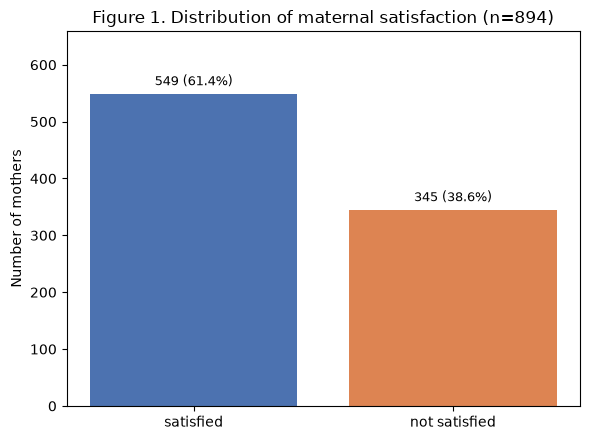

In [15]:
fig, ax = plt.subplots(figsize=(6,4.5))
counts = data['satisfaction'].value_counts()
colors = ['#4C72B0','#DD8452']
ax.bar(counts.index.astype(str), counts.values, color=colors)
for i,v in enumerate(counts.values):
    ax.text(i, v+15, f"{v} ({v/len(data)*100:.1f}%)", ha='center', fontsize=9)
ax.set_ylabel('Number of mothers')
ax.set_ylim(0, max(counts.values)*1.2)
ax.set_title('Figure 1. Distribution of maternal satisfaction (n=894)', fontsize=12)
plt.tight_layout()
#plt.savefig('C:/Users/User/Downloads/Delivery care figure1.png')
#plt.close()

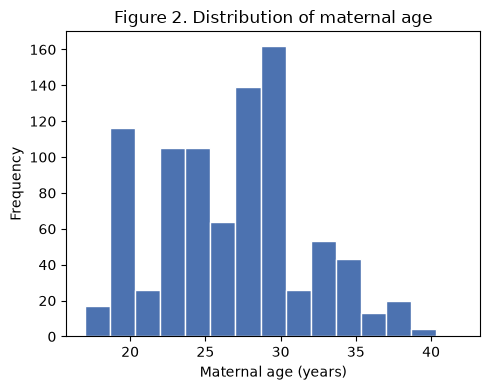

In [16]:
# 2. Age histogram
fig, ax = plt.subplots(figsize=(5,4))
ax.hist(data['q101age'], bins=15, color='#4C72B0', edgecolor='white')
ax.set_xlabel('Maternal age (years)')
ax.set_ylabel('Frequency')
ax.set_title('Figure 2. Distribution of maternal age')
plt.tight_layout()
#plt.savefig('C:/Users/User/Downloads/Delivery care figure2.png')
#plt.close()

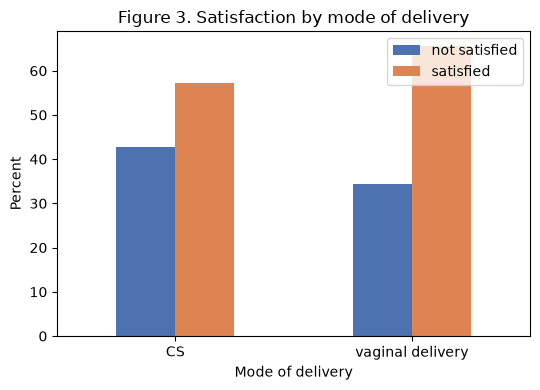

In [17]:
# 3. Mode of delivery vs satisfaction
fig, ax = plt.subplots(figsize=(5.5,4))
ct = pd.crosstab(data['modeofdeliveryrecode'], data['satisfaction'], normalize='index')*100
ct.plot(kind='bar', ax=ax, color=colors)
ax.set_ylabel('Percent')
ax.set_xlabel('Mode of delivery')
ax.set_title('Figure 3. Satisfaction by mode of delivery')
ax.legend(title='')
plt.xticks(rotation=0)
plt.tight_layout()
#plt.savefig('C:/Users/User/Downloads/Delivery care figure3.png')
#plt.close()

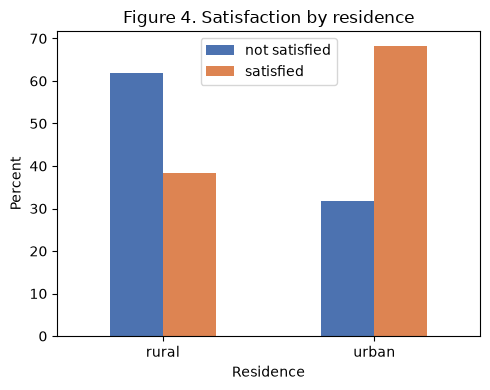

In [18]:
# 4. Residence vs satisfaction
fig, ax = plt.subplots(figsize=(5,4))
ct2 = pd.crosstab(data['q108reside'], data['satisfaction'], normalize='index')*100
ct2.plot(kind='bar', ax=ax, color=colors)
ax.set_ylabel('Percent')
ax.set_xlabel('Residence')
ax.set_title('Figure 4. Satisfaction by residence')
ax.legend(title='')
plt.xticks(rotation=0)
plt.tight_layout()
#plt.savefig('C:/Users/User/Downloads/Delivery care figure4.png')
#plt.close()


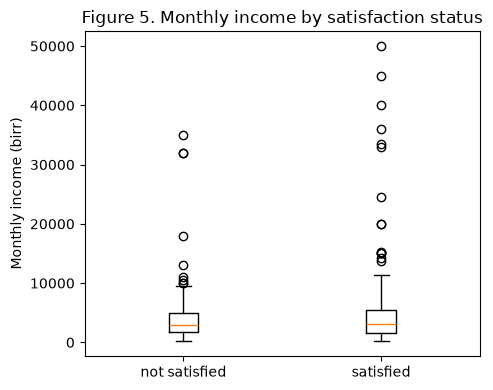

In [19]:
# Ensure satisfaction is categorical
if not isinstance(data['satisfaction'].dtype, pd.CategoricalDtype):
    data['satisfaction'] = data['satisfaction'].astype('category')

# Get unique categories as a list
categories = list(data['satisfaction'].cat.categories)

# Extract income data per category
data_sat = [data.loc[data['satisfaction'] == lvl, 'q107mincom'].dropna() for lvl in categories]

# Plot
fig, ax = plt.subplots(figsize=(5, 4))
ax.boxplot(data_sat, tick_labels=categories)  # Updated to tick_labels
ax.set_ylabel('Monthly income (birr)')
ax.set_title('Figure 5. Monthly income by satisfaction status')
plt.tight_layout()
plt.show()

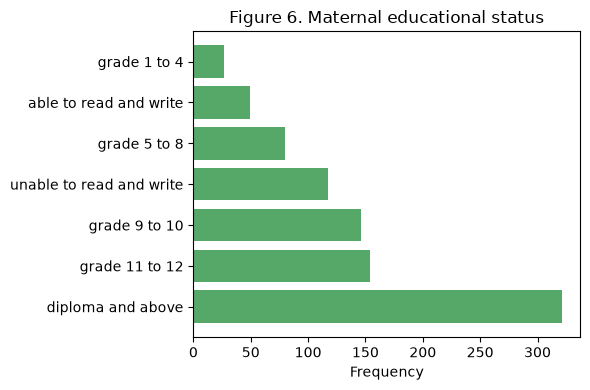

In [20]:
# 6. Education level distribution
fig, ax = plt.subplots(figsize=(6,4))
edu = data['q105educat'].value_counts()
ax.barh(edu.index.astype(str), edu.values, color='#55A868')
ax.set_xlabel('Frequency')
ax.set_title('Figure 6. Maternal educational status')
plt.tight_layout()
#plt.savefig('/home/claude/proj/figs/fig6_education.png')
#plt.close()


In [21]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [22]:
drop_cols = ['q1092disth', 'wolkingdistancerecodeinhrs']
duplicate_raw = ['ageafterrecod', 'monthlyincomerecode', 'gestationaagerecode',
                  'birthweightofbaby', 'distancerecode1']
data_model = data.drop(columns=drop_cols + duplicate_raw)

In [23]:
# Recode 88.0 (non-response code accidentally left in q103religi) to NaN, then
# impute with mode (only 5 cases)
data_model['q103religi'] = data_model['q103religi'].replace({88.0: np.nan})
data_model['q103religi'] = data_model['q103religi'].astype('object')
data_model['q103religi'] = data_model['q103religi'].fillna(data_model['q103religi'].mode()[0])

In [24]:
# STEP 2B. TARGET / FEATURES
# -----------------------------------------------------------------------
y = (data_model['satisfaction'] == 'satisfied').astype(int)
X = data_model.drop(columns=['satisfaction'])

In [25]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()
print("\nNumeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['q101age', 'q107mincom', 'q1091distk', 'q205ga', 'q2010bw']
Categorical features: ['q102mstatu', 'q103religi', 'q104ethini', 'q105educat', 'q106occupa', 'q108reside', 'q110reason', 'q111timeta', 'q112waitpl', 'q113privac', 'q201parity', 'q202cpplan', 'q203ancatt', 'q204hivres', 'q206delimo', 'q207nstatu', 'q208pdhsta', 'q209nsex', 'q301greeti', 'q302respec', 'q303delive', 'q411owners', 'modeofdeliveryrecode', 'waitingtimerecode', 'privacyrecode', 'encourageandsupportatdeliveryrecode', 'politenessrecode', 'availabilityofmedicalequipmentsrecode', 'counselingrecode', 'overallcleanessrecode', 'accessandcleanessoftoiletrecode', 'waitingareacleanessandconfort', 'availabilityofbedintheward']


In [26]:
# STEP 2C. TRAIN / TEST SPLIT (75/25, stratified)
# -----------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
print(f"\nTrain size: {X_train.shape[0]}  Test size: {X_test.shape[0]}")
print(f"Train outcome balance: {y_train.mean():.3f}  Test outcome balance: {y_test.mean():.3f}")


Train size: 715  Test size: 179
Train outcome balance: 0.614  Test outcome balance: 0.615


In [27]:
# STEP 2D. PREPROCESSING PIPELINE (scale numeric, one-hot encode categorical)
# -----------------------------------------------------------------------
preprocess = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
])

In [28]:
# STEP 2E. FEATURE SELECTION: univariate association with outcome
# (mutual information on full encoded design matrix -> pick informative ones)
# -----------------------------------------------------------------------
X_train_enc = preprocess.fit_transform(X_train)
feature_names = (numeric_features +
                  list(preprocess.named_transformers_['cat'].get_feature_names_out(categorical_features)))
mi = mutual_info_classif(X_train_enc, y_train, random_state=RANDOM_STATE)
mi_table = pd.DataFrame({'feature': feature_names, 'mutual_info': mi}).sort_values('mutual_info', ascending=False)
#mi_table.to_csv('/home/claude/proj/table3_mutual_information_ranking.csv', index=False)
print("\nTop 15 features by mutual information with satisfaction:")
print(mi_table.head(15).to_string(index=False))


Top 15 features by mutual information with satisfaction:
                                        feature  mutual_info
      accessandcleanessoftoiletrecode_satisfied     0.436137
           availabilityofbedintheward_satisfied     0.432060
        waitingareacleanessandconfort_satisfied     0.423742
                overallcleanessrecode_satisfied     0.387764
                        privacyrecode_satisfied     0.247517
                     politenessrecode_satisfied     0.210442
                                 q302respec_yes     0.201835
                     counselingrecode_satisfied     0.199776
  encourageandsupportatdeliveryrecode_satisfied     0.198593
                    waitingtimerecode_satisfied     0.190854
                                 q113privac_yes     0.173907
                                 q112waitpl_yes     0.168889
                                 q301greeti_yes     0.164340
availabilityofmedicalequipmentsrecode_satisfied     0.146211
                           

In [29]:
# -----------------------------------------------------------------------
# STEP 3. FIT LOGISTIC REGRESSION (full pipeline, all cleaned features,
#          L2-regularised, class_weight balanced since classes are 61/39)
# -----------------------------------------------------------------------
logit_pipeline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE,
                                class_weight='balanced'))
])
logit_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](38,)","['q101age','q102mstatu','q103religi',...,'accessandcleanessoftoiletrecode', 'waitingareacleanessandconfort','availabilityofbedintheward']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,38
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default 

In [30]:
# STEP 4. MODEL EVALUATION ON HELD-OUT TEST SET
# -----------------------------------------------------------------------
y_pred = logit_pipeline.predict(X_test)
y_proba = logit_pipeline.predict_proba(X_test)[:, 1]

metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall (Sensitivity)': recall_score(y_test, y_pred),
    'F1 score': f1_score(y_test, y_pred),
    'AUC-ROC': roc_auc_score(y_test, y_proba),
    'Brier score': brier_score_loss(y_test, y_proba),
}
print("\n" + "="*60)
print("MODEL PERFORMANCE ON TEST SET (n={})".format(len(y_test)))
print("="*60)
for k, v in metrics.items():
    print(f"{k:25s}: {v:.3f}")

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion matrix (rows=actual, cols=predicted) [not satisfied, satisfied]:")
print(cm)

print("\nFull classification report:")
print(classification_report(y_test, y_pred, target_names=['not satisfied','satisfied']))

#pd.DataFrame([metrics]).T.rename(columns={0: 'value'}).to_csv('/home/claude/proj/table4_model_performance.csv')


MODEL PERFORMANCE ON TEST SET (n=179)
Accuracy                 : 0.950
Precision                : 0.990
Recall (Sensitivity)     : 0.927
F1 score                 : 0.958
AUC-ROC                  : 0.991
Brier score              : 0.037

Confusion matrix (rows=actual, cols=predicted) [not satisfied, satisfied]:
[[ 68   1]
 [  8 102]]

Full classification report:
               precision    recall  f1-score   support

not satisfied       0.89      0.99      0.94        69
    satisfied       0.99      0.93      0.96       110

     accuracy                           0.95       179
    macro avg       0.94      0.96      0.95       179
 weighted avg       0.95      0.95      0.95       179



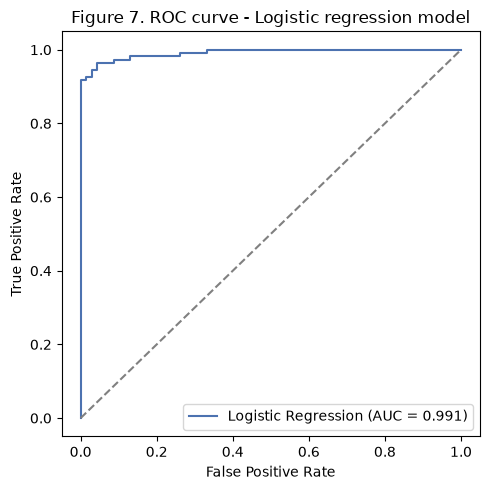

In [31]:
# ROC curve plot
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {metrics['AUC-ROC']:.3f})", color='#4C72B0')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Figure 7. ROC curve - Logistic regression model')
plt.legend(loc='lower right')
plt.tight_layout()
#plt.savefig('/home/claude/proj/figs/fig7_roc_curve.png')
#plt.close()

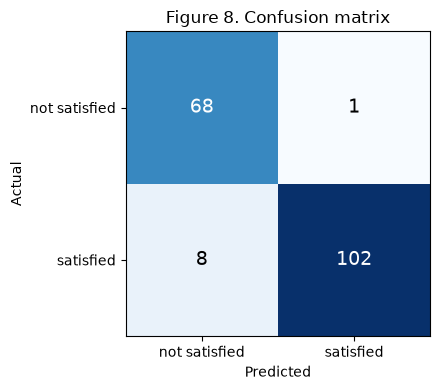

In [32]:
# Confusion matrix heatmap
plt.figure(figsize=(4.5,4))
plt.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha='center', va='center', fontsize=14,
                  color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.xticks([0,1], ['not satisfied','satisfied'])
plt.yticks([0,1], ['not satisfied','satisfied'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Figure 8. Confusion matrix')
plt.tight_layout()
#plt.savefig('/home/claude/proj/figs/fig8_confusion_matrix.png')
#plt.close()

In [33]:
# STEP 5. FEATURE IMPORTANCE (logistic coefficients = relative importance;
#          plus model-agnostic permutation importance for confirmation)
# -----------------------------------------------------------------------
coefs = logit_pipeline.named_steps['clf'].coef_[0]
coef_table = pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
coef_table['odds_ratio'] = np.exp(coef_table['coefficient'])
coef_table['abs_coef'] = coef_table['coefficient'].abs()
coef_table = coef_table.sort_values('abs_coef', ascending=False)
#coef_table.to_csv('/home/claude/proj/table5_logistic_coefficients.csv', index=False)
print("\nTop 15 predictors by logistic regression coefficient magnitude (relative importance):")
print(coef_table.head(15)[['feature','coefficient','odds_ratio']].to_string(index=False))

perm = permutation_importance(logit_pipeline, X_test, y_test, n_repeats=30,
                               random_state=RANDOM_STATE, scoring='roc_auc')
perm_table = pd.DataFrame({'feature': X.columns, 'perm_importance_mean': perm.importances_mean,
                            'perm_importance_std': perm.importances_std}).sort_values(
                            'perm_importance_mean', ascending=False)
#perm_table.to_csv('/home/claude/proj/table6_permutation_importance.csv', index=False)
print("\nPermutation importance (drop in AUC when feature is shuffled), top 10:")
print(perm_table.head(10).to_string(index=False))


Top 15 predictors by logistic regression coefficient magnitude (relative importance):
                                        feature  coefficient  odds_ratio
                overallcleanessrecode_satisfied     2.047689    7.749971
      accessandcleanessoftoiletrecode_satisfied     1.971141    7.178860
        waitingareacleanessandconfort_satisfied     1.755529    5.786510
           availabilityofbedintheward_satisfied     1.733153    5.658466
                        privacyrecode_satisfied     1.691008    5.424944
availabilityofmedicalequipmentsrecode_satisfied     1.665594    5.288813
                     counselingrecode_satisfied     1.329691    3.779876
                     politenessrecode_satisfied     1.252962    3.500696
                                 q203ancatt_yes     1.064478    2.899325
                    waitingtimerecode_satisfied     0.988591    2.687445
                              q106occupa_others     0.872615    2.393161
  encourageandsupportatdeliveryrecode

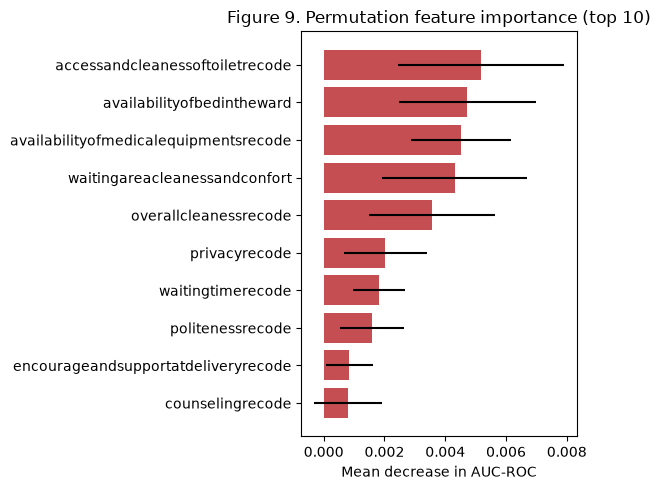

In [34]:
# Plot top 10 permutation importance
top10 = perm_table.head(10).iloc[::-1]
plt.figure(figsize=(6,5))
plt.barh(top10['feature'], top10['perm_importance_mean'], xerr=top10['perm_importance_std'], color='#C44E52')
plt.xlabel('Mean decrease in AUC-ROC')
plt.title('Figure 9. Permutation feature importance (top 10)')
plt.tight_layout()
#plt.savefig('/home/claude/proj/figs/fig9_permutation_importance.png')
#plt.close()

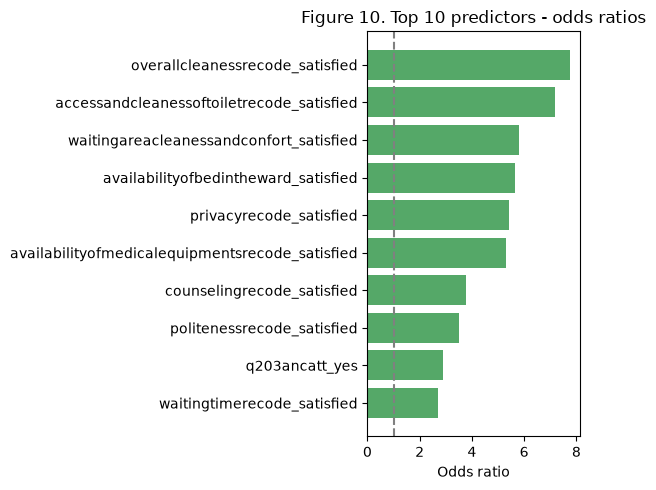

In [35]:
# Plot top 10 odds ratios
top10c = coef_table.head(10).iloc[::-1]
plt.figure(figsize=(6,5))
colors_bar = ['#55A868' if c>0 else '#C44E52' for c in top10c['coefficient']]
plt.barh(top10c['feature'], top10c['odds_ratio'], color=colors_bar)
plt.axvline(1, color='gray', linestyle='--')
plt.xlabel('Odds ratio')
plt.title('Figure 10. Top 10 predictors - odds ratios')
plt.tight_layout()
#plt.savefig('/home/claude/proj/figs/fig10_odds_ratios.png')
#plt.close()

In [36]:
# STEP 6. MODEL DEPLOYMENT
# -----------------------------------------------------------------------
joblib.dump(logit_pipeline, 'C:/Users/User/Downloads/Telegram Desktop/satisfaction_logit_model.pkl')
with open('C:/Users/User/Downloads/Telegram Desktop/feature_schema.json','w') as f:
    json.dump({'numeric_features': numeric_features, 'categorical_features': categorical_features}, f, indent=2)
print("\nModel deployed/saved to satisfaction_logit_model.pkl")

# Demonstration: simulate scoring 3 new (unseen) patients using the saved model
sample_new_patients = X_test.iloc[:3].copy()
loaded_model = joblib.load('C:/Users/User/Downloads/Telegram Desktop/satisfaction_logit_model.pkl')
pred_labels = loaded_model.predict(sample_new_patients)
pred_probs = loaded_model.predict_proba(sample_new_patients)[:,1]
print("\nDEPLOYMENT DEMO: scoring 3 new patient records with the saved model")
for i in range(3):
    print(f" Patient {i+1}: predicted = {'satisfied' if pred_labels[i]==1 else 'not satisfied'}"
          f"  (P(satisfied) = {pred_probs[i]:.3f})  [actual = {'satisfied' if y_test.iloc[i]==1 else 'not satisfied'}]")



Model deployed/saved to satisfaction_logit_model.pkl

DEPLOYMENT DEMO: scoring 3 new patient records with the saved model
 Patient 1: predicted = satisfied  (P(satisfied) = 0.819)  [actual = not satisfied]
 Patient 2: predicted = satisfied  (P(satisfied) = 0.998)  [actual = satisfied]
 Patient 3: predicted = satisfied  (P(satisfied) = 0.992)  [actual = satisfied]


In [37]:
satisfaction_domain_items = ['waitingtimerecode','privacyrecode',
    'encourageandsupportatdeliveryrecode','politenessrecode',
    'availabilityofmedicalequipmentsrecode','counselingrecode',
    'overallcleanessrecode','accessandcleanessoftoiletrecode',
    'waitingareacleanessandconfort','availabilityofbedintheward',
    # raw pre-recode duplicates of the same constructs
    'q111timeta','q112waitpl','q113privac','q301greeti','q302respec']

In [38]:
drop_cols = ['q1092disth','wolkingdistancerecodeinhrs',
             'ageafterrecod','monthlyincomerecode','gestationaagerecode',
             'birthweightofbaby','distancerecode1'] + satisfaction_domain_items

In [39]:
data_model = data.drop(columns=drop_cols)
data_model['q103religi'] = data_model['q103religi'].replace({88.0: np.nan}).astype('object')
data_model['q103religi'] = data_model['q103religi'].fillna(data_model['q103religi'].mode()[0])

y = (data_model['satisfaction'] == 'satisfied').astype(int)
X = data_model.drop(columns=['satisfaction'])
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()
print("Model B (socio-demographic/obstetric only) features:")
print(" Numeric:", numeric_features)
print(" Categorical:", categorical_features)


Model B (socio-demographic/obstetric only) features:
 Numeric: ['q101age', 'q107mincom', 'q1091distk', 'q205ga', 'q2010bw']
 Categorical: ['q102mstatu', 'q103religi', 'q104ethini', 'q105educat', 'q106occupa', 'q108reside', 'q110reason', 'q201parity', 'q202cpplan', 'q203ancatt', 'q204hivres', 'q206delimo', 'q207nstatu', 'q208pdhsta', 'q209nsex', 'q303delive', 'q411owners', 'modeofdeliveryrecode']


In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

In [41]:
preprocess = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
])
pipe = Pipeline([('preprocess', preprocess),
                  ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE,
                                              class_weight='balanced'))])
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](23,)","['q101age','q102mstatu','q103religi',...,'q303delive','q411owners', 'modeofdeliveryrecode']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,23
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pass

In [43]:
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:,1]
metrics_b = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall (Sensitivity)': recall_score(y_test, y_pred),
    'F1 score': f1_score(y_test, y_pred),
    'AUC-ROC': roc_auc_score(y_test, y_proba),
    'Brier score': brier_score_loss(y_test, y_proba),
}
print("\nMODEL B PERFORMANCE (socio-demographic/obstetric/facility predictors only):")
for k,v in metrics_b.items():
    print(f"{k:25s}: {v:.3f}")
#pd.DataFrame([metrics_b]).T.rename(columns={0:'value'}).to_csv('/home/claude/proj/table4b_modelB_performance.csv')
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion matrix Model B:\n", cm)


MODEL B PERFORMANCE (socio-demographic/obstetric/facility predictors only):
Accuracy                 : 0.759
Precision                : 0.850
Recall (Sensitivity)     : 0.739
F1 score                 : 0.791
AUC-ROC                  : 0.841
Brier score              : 0.163

Confusion matrix Model B:
 [[ 68  18]
 [ 36 102]]


In [44]:
feature_names = (numeric_features +
                  list(pipe.named_steps['preprocess'].named_transformers_['cat'].get_feature_names_out(categorical_features)))
coefs = pipe.named_steps['clf'].coef_[0]
coef_table = pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
coef_table['odds_ratio'] = np.exp(coef_table['coefficient'])
coef_table['abs_coef'] = coef_table['coefficient'].abs()
coef_table = coef_table.sort_values('abs_coef', ascending=False)
#coef_table.to_csv('/home/claude/proj/table5b_modelB_coefficients.csv', index=False)
print("\nTop 10 Model B predictors:")
print(coef_table.head(10)[['feature','coefficient','odds_ratio']].to_string(index=False))


Top 10 Model B predictors:
                  feature  coefficient  odds_ratio
       q411owners_private     2.602215   13.493595
  q201parity_>5 childrens     1.240025    3.455700
q105educat_grade 11 to 12    -0.958870    0.383326
           q203ancatt_yes     0.928735    2.531306
       q110reason_refered    -0.902144    0.405699
         q108reside_urban     0.885743    2.424786
        q106occupa_others     0.862559    2.369215
      q102mstatu_divorced    -0.813082    0.443489
      q106occupa_students    -0.716008    0.488699
       q102mstatu_widowed    -0.658829    0.517457


In [45]:
perm = permutation_importance(pipe, X_test, y_test, n_repeats=30, random_state=RANDOM_STATE, scoring='roc_auc')
perm_table = pd.DataFrame({'feature': X.columns, 'perm_importance_mean': perm.importances_mean}).sort_values(
    'perm_importance_mean', ascending=False)
#perm_table.to_csv('/home/claude/proj/table6b_modelB_permutation_importance.csv', index=False)
print("\nModel B permutation importance, top 10:")
print(perm_table.head(10).to_string(index=False))


Model B permutation importance, top 10:
             feature  perm_importance_mean
          q411owners              0.091279
          q110reason              0.040613
          q108reside              0.019925
          q103religi              0.012524
          q303delive              0.012369
          q106occupa              0.008409
          q201parity              0.008364
          q105educat              0.007179
modeofdeliveryrecode              0.006772
          q102mstatu              0.006569


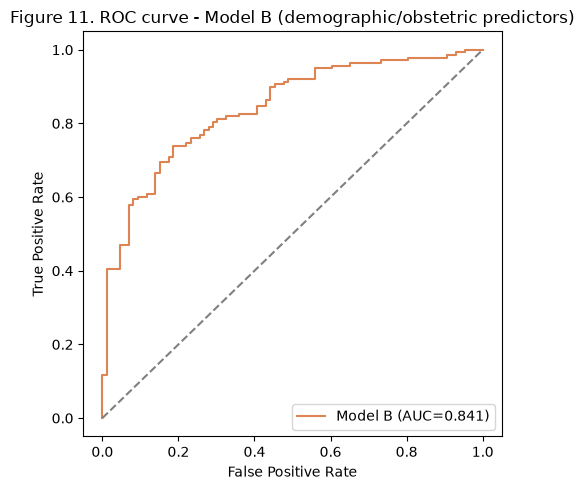

In [46]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"Model B (AUC={metrics_b['AUC-ROC']:.3f})", color='#DD8452')
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Figure 11. ROC curve - Model B (demographic/obstetric predictors)')
plt.legend(loc='lower right')
plt.tight_layout()
#plt.savefig('/home/claude/proj/figs/fig11_roc_modelB.png')
#plt.close()

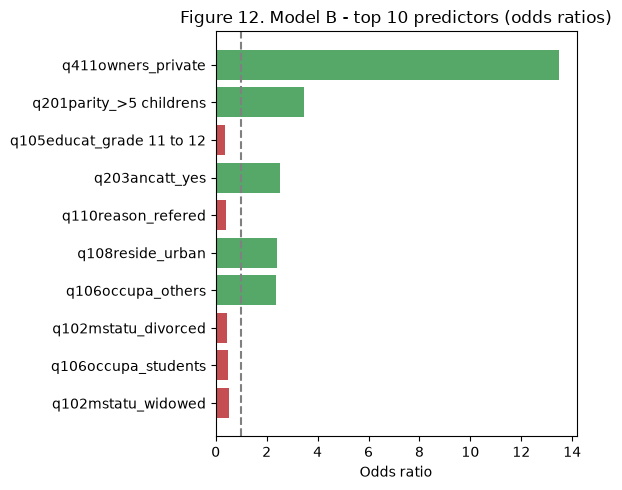

In [47]:
top10c = coef_table.head(10).iloc[::-1]
plt.figure(figsize=(6,5))
colors_bar = ['#55A868' if c>0 else '#C44E52' for c in top10c['coefficient']]
plt.barh(top10c['feature'], top10c['odds_ratio'], color=colors_bar)
plt.axvline(1, color='gray', linestyle='--')
plt.xlabel('Odds ratio')
plt.title('Figure 12. Model B - top 10 predictors (odds ratios)')
plt.tight_layout()
#plt.savefig('/home/claude/proj/figs/fig12_modelB_odds_ratios.png')
#plt.close()

In [51]:
joblib.dump(pipe, 'C:/Users/User/Downloads/Telegram Desktop/satisfaction_logit_modelB.pkl')
print("\nModel B saved to satisfaction_logit_modelB.pkl")


Model B saved to satisfaction_logit_modelB.pkl
